In [4]:
%autoreload 2

UsageError: Line magic function `%autoreload` not found.


In [2]:
import model as md
import model_2 as m
import numpy as np
import matplotlib.pyplot as plt
import importlib
importlib.reload(md)
N = 1000


/Users/talizou/Documents/Physics_The_Projects-1/Spike_code/model.py:101: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel(f'$\lambda$')


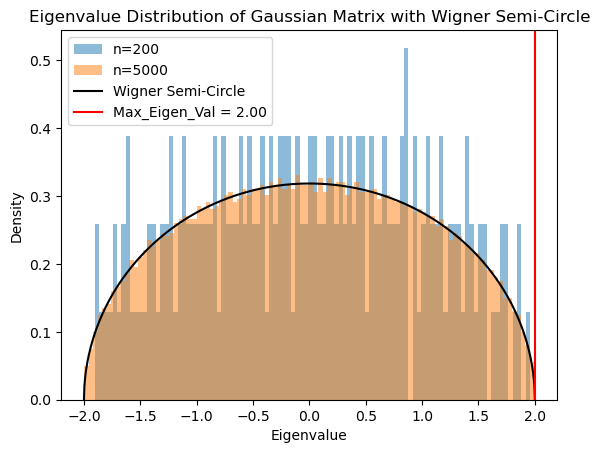

In [ ]:
for N in [200, 5000]:

    M = md.symmetric_gaussian_matrix(N)
    md.plot_eigenvalue_distribution(M, N)
md.show('Eigenvalue', 'Density', 'Eigenvalue Distribution of Gaussian Matrix with Wigner Semi-Circle', 'No_Spike', False, True, True )


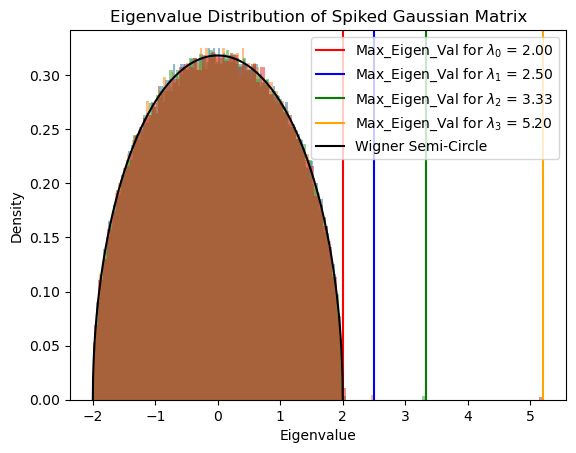

In [20]:
#Location of the Spikes:
importlib.reload(md)

lambas = [1, 2, 3, 5]
N = 5000
colors = ['red', 'blue', 'green', 'orange']
i = 0
for lamba in lambas:
    spiked_gaussian = md.spiked_gaussian_matrix(N, lamba)
    md.plot_eigenvalue_distribution(spiked_gaussian, N, True)
    md.plot_Max_Eigenval(lamba, colors, i)
    i += 1

plt.xlabel('Eigenvalue')
plt.ylabel('Density')
md.plot_Wigner_Semi_Circle()
plt.title('Eigenvalue Distribution of Spiked Gaussian Matrix')
plt.legend()

plt.savefig('../Plots/Spike/many_spikes.png')
plt.show()


/Users/talizou/Documents/Physics_The_Projects-1/Spike_code/model.py:101: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Lambda')


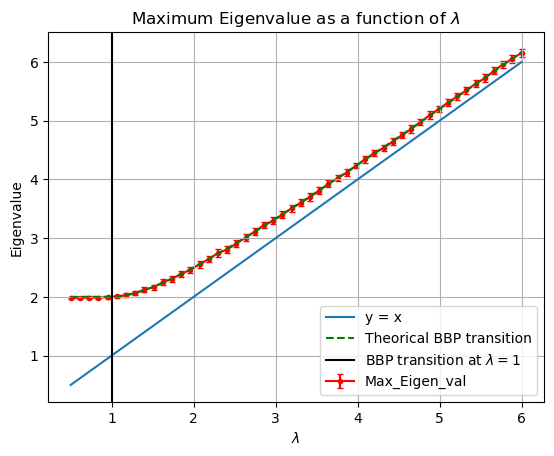

In [38]:
importlib.reload(md)
md.first_look_at_BBP_transi(500)

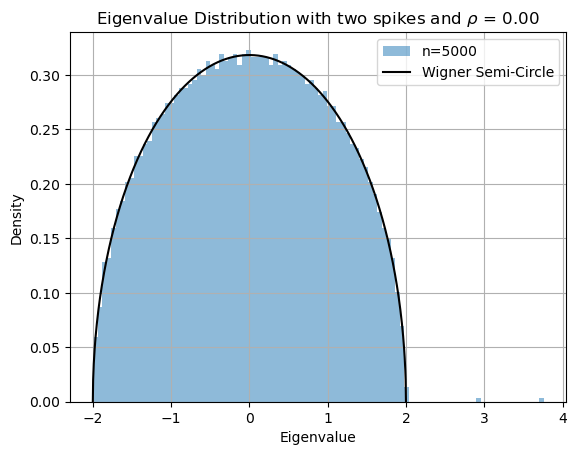

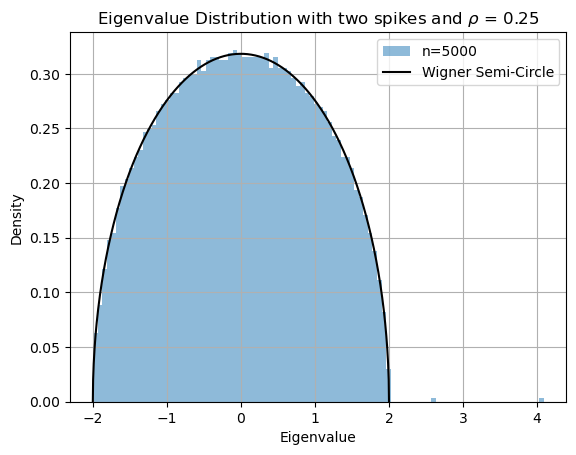

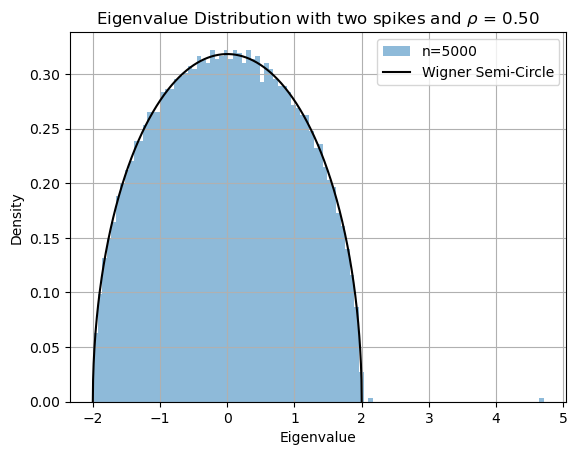

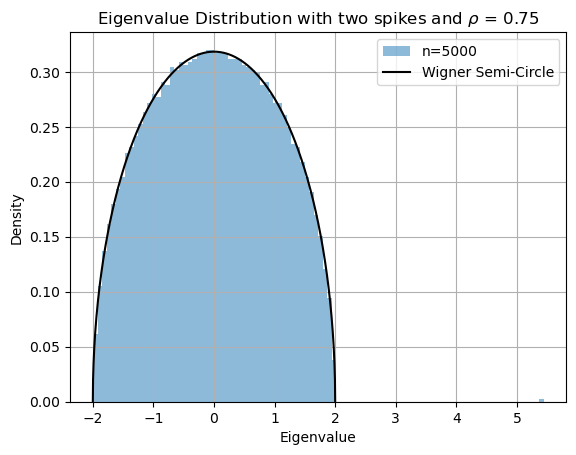

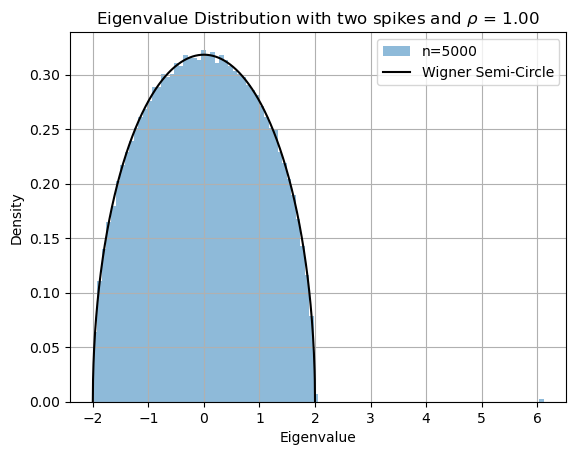

In [30]:
importlib.reload(m)
rhos = np.linspace(0, 1, 5)
lamba_1 = 5
lamba_2 = 4
alpha = 0.5
N = 5000

for rho in rhos:
    M = m.TwoSpikedWignerMatrix(N, lamba_1, lamba_2, rho, alpha)
    M.plot_eigenvalue_distribution()
    M.ploplote(title = rf'Eigenvalue Distribution with two spikes and $\rho$ = {rho:.2f}', savefig = f'Two_Spiked_Wigner_rho_{rho:.2f}', Wigner=True, grid=True)

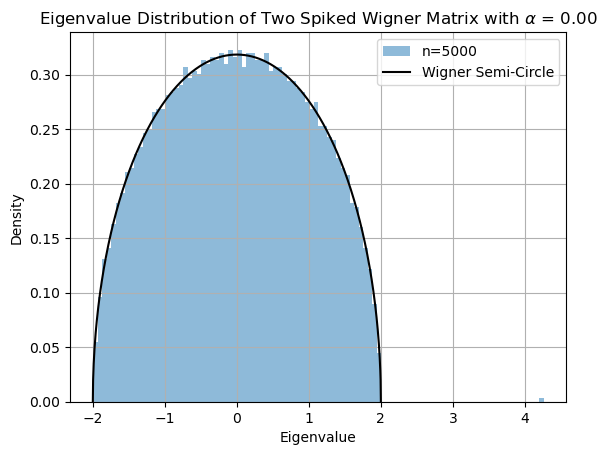

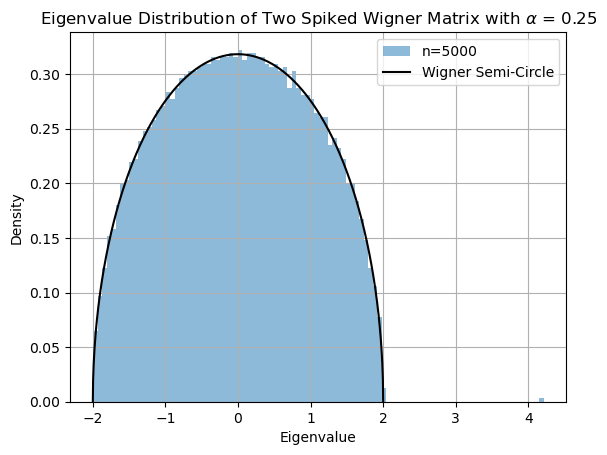

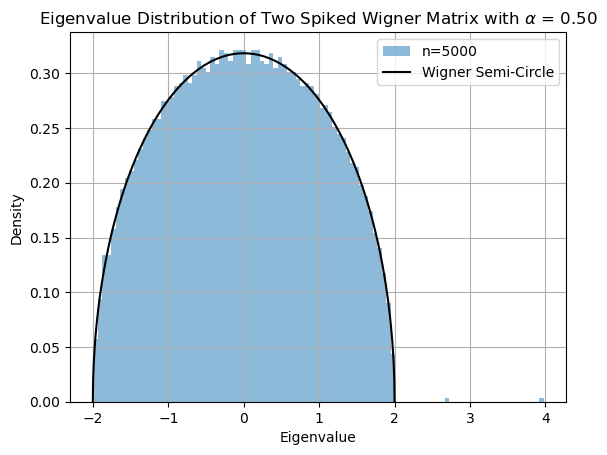

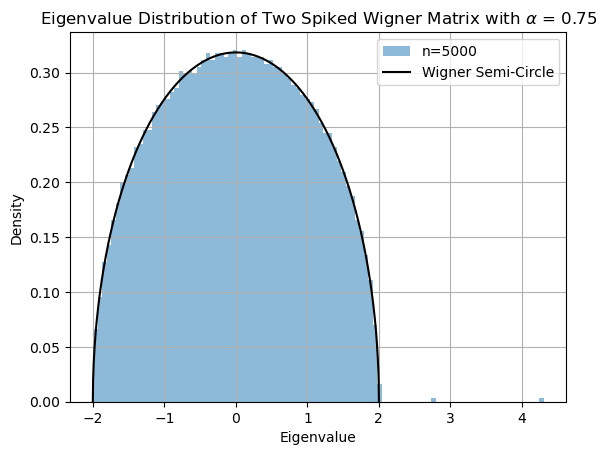

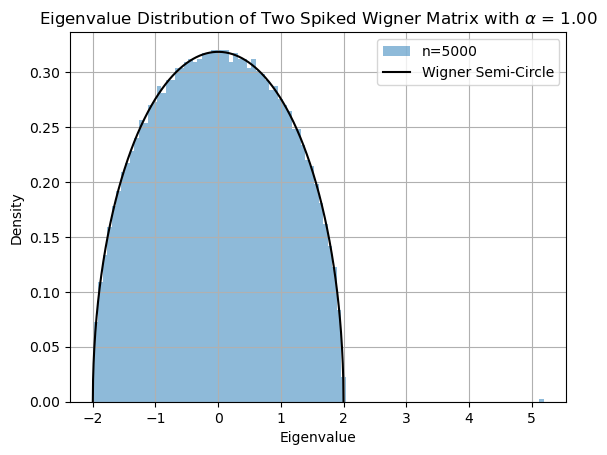

In [ ]:
importlib.reload(m)
alphas = np.linspace(0, 1, 5)
lamba_1 = 5
lamba_2 = 4
rho = 0.2
N = 5000

for alpha in alphas:
    M = m.TwoSpikedWignerMatrix(N, lamba_1, lamba_2, rho, alpha)
    M.plot_eigenvalue_distribution()
    
    M.ploplote(title = rf'Eigenvalue Distribution of Two Spiked Wigner Matrix with $\alpha$ = {alpha:.2f}', savefig = f'Two_Spiked_Wigner_alpha_{alpha:.2f}', Wigner=True, grid=True)

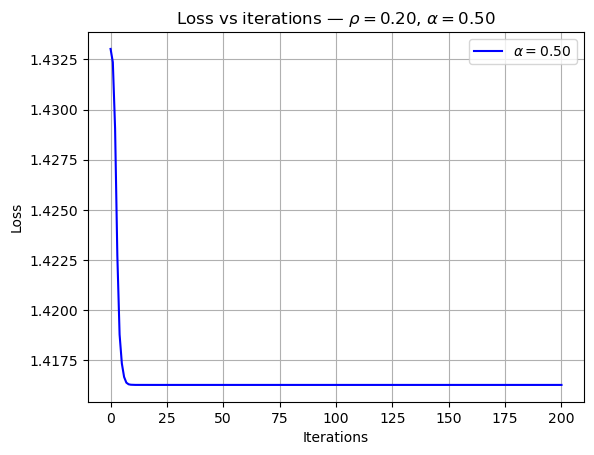

In [ ]:
importlib.reload(m)

alpha = 0.5
N = 500
rho = 0.2
lamba_1 = 7
lamba_2 = 3
N_iter = 200
N_runs = 20

M = m.TwoSpikedWignerMatrix(N, lamba_1, lamba_2, rho, alpha)

all_losses = []
for _ in range(N_runs):
    x_hat = np.random.normal(0, 1, N)
    x_hat /= np.linalg.norm(x_hat)
    run_losses = [M.loss(x_hat)]
    for _ in range(N_iter):
        x_hat = M.matrix @ x_hat
        x_hat /= np.linalg.norm(x_hat)
        run_losses.append(M.loss(x_hat))
    all_losses.append(run_losses)

all_losses = np.array(all_losses)  # (N_runs, N_iter+1)
mean_loss = all_losses.mean(axis=0)
std_loss = all_losses.std(axis=0)
iterations = np.arange(N_iter + 1)

plt.plot(iterations, mean_loss, color='blue', label=rf'$\alpha={alpha:.2f}$')

m.ploplote_moi_ca(
    xlabel='Iterations',
    ylabel='Loss',
    title=rf'Loss vs iterations — $\rho={rho:.2f}$, $\alpha={alpha:.2f}$',
    savefig='Loss_vs_Iter',
    grid=True,
    legend=True,
)

FileNotFoundError: [Errno 2] No such file or directory: './Plots/Spike/FinalBoss_alpha=0.50.png'

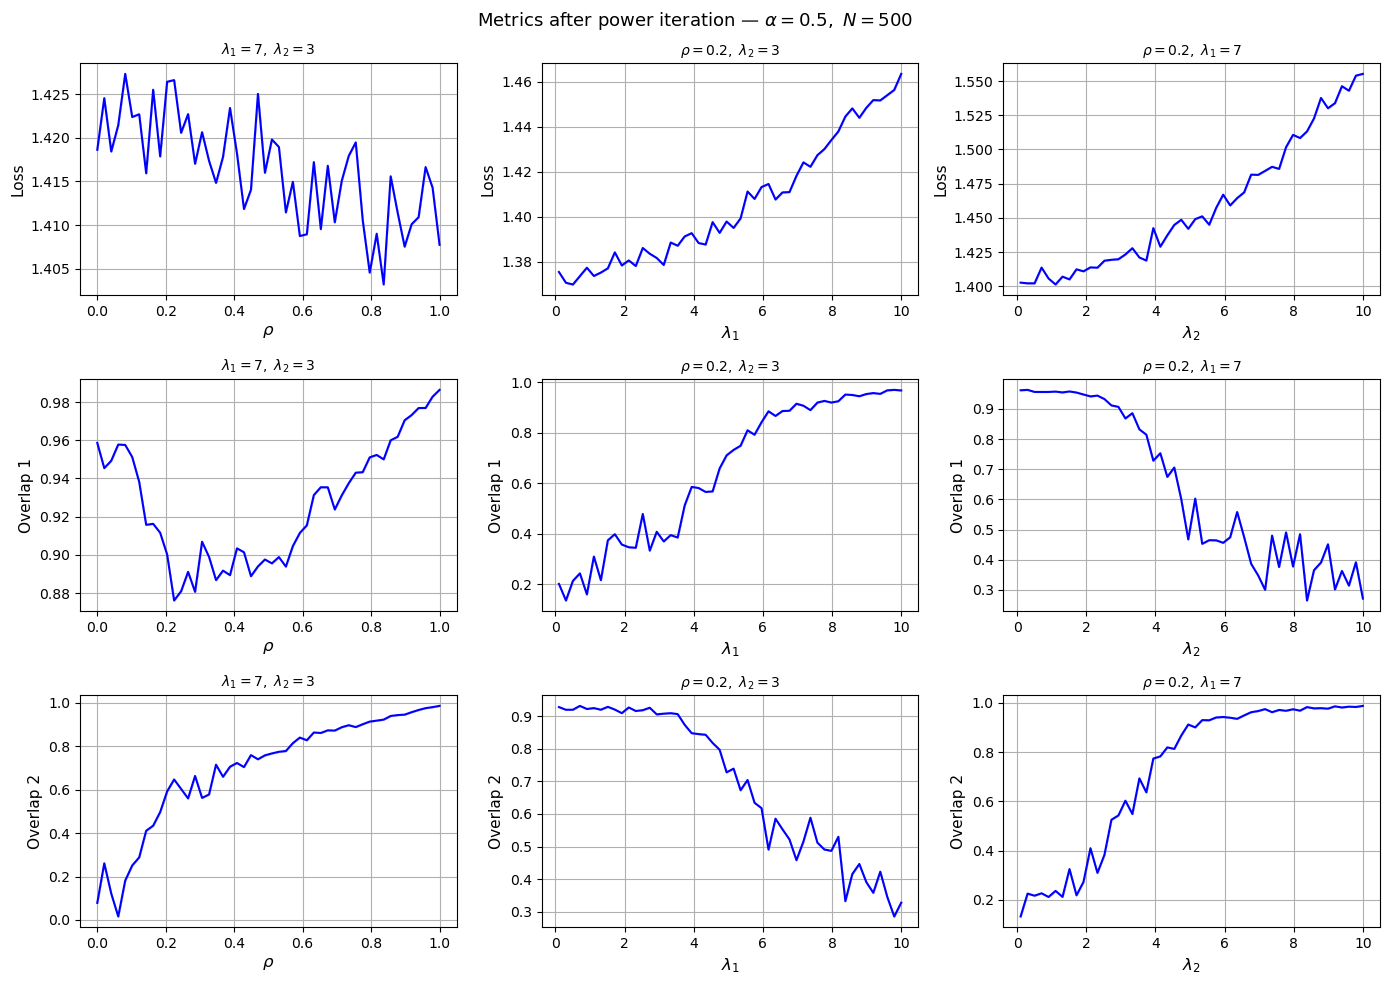

In [ ]:
importlib.reload(m)

alpha = 0.5
N = 500
N_iter = 200
N_runs = 20

# Fixed values
lamba_1_fixed = 7
lamba_2_fixed = 3
rho_fixed = 0.2

# Sweep ranges
rhos      = np.linspace(0, 1, 50)
lambas_1  = np.linspace(0.1, 10, 50)
lambas_2  = np.linspace(0.1, 10, 50)

def run_metrics(M, N_runs, N_iter):
    """Run power iteration N_runs times, return mean/std of loss, overlap1, overlap2."""
    all_loss, all_ov1, all_ov2 = [], [], []
    for _ in range(N_runs):
        x_hat = np.random.normal(0, 1, N)
        x_hat /= np.linalg.norm(x_hat)
        for _ in range(N_iter):
            x_hat = M.matrix @ x_hat
            x_hat /= np.linalg.norm(x_hat)
        all_loss.append(M.loss(x_hat))
        all_ov1.append(M.overlap1(x_hat))
        all_ov2.append(M.overlap2(x_hat))
    return (np.mean(all_loss),  np.std(all_loss),
            np.mean(all_ov1),   np.std(all_ov1),
            np.mean(all_ov2),   np.std(all_ov2))

# --- Collect data ---
results = {"rho": [], "lam1": [], "lam2": []}

for rho in rhos:
    results["rho"].append(run_metrics(m.TwoSpikedWignerMatrix(N, lamba_1_fixed, lamba_2_fixed, rho, alpha), N_runs, N_iter))

for lam1 in lambas_1:
    results["lam1"].append(run_metrics(m.TwoSpikedWignerMatrix(N, lam1, lamba_2_fixed, rho_fixed, alpha), N_runs, N_iter))

for lam2 in lambas_2:
    results["lam2"].append(run_metrics(m.TwoSpikedWignerMatrix(N, lamba_1_fixed, lam2, rho_fixed, alpha), N_runs, N_iter))

# Convert to arrays: columns are (loss_mean, loss_std, ov1_mean, ov1_std, ov2_mean, ov2_std)
for k in results:
    results[k] = np.array(results[k])

# --- Plot ---
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

sweep_params = [
    (rhos,     results["rho"], r"$\rho$",         rf"$\lambda_1={lamba_1_fixed},\ \lambda_2={lamba_2_fixed}$"),
    (lambas_1, results["lam1"], r"$\lambda_1$",   rf"$\rho={rho_fixed},\ \lambda_2={lamba_2_fixed}$"),
    (lambas_2, results["lam2"], r"$\lambda_2$",   rf"$\rho={rho_fixed},\ \lambda_1={lamba_1_fixed}$"),
]
metrics = [
    (0, 1, "Loss"),
    (2, 3, "Overlap 1"),
    (4, 5, "Overlap 2"),
]

for col, (x, data, xlabel, subtitle) in enumerate(sweep_params):
    for row, (mi, si, ylabel) in enumerate(metrics):
        ax = axes[row, col]
        ax.plot(x, data[:, mi], color='blue')
        ax.fill_between(x, data[:, mi] - data[:, si], data[:, mi] + data[:, si], alpha=0.2, color='blue')
        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(subtitle, fontsize=10)
        ax.grid(True)

fig.suptitle(rf"Metrics after power iteration — $\alpha={alpha},\ N={N}$", fontsize=13)
fig.tight_layout()

fig.savefig(f"../Plots/Spike/FinalBoss_alpha={alpha:.2f}.png", dpi=200, bbox_inches="tight")
plt.show()

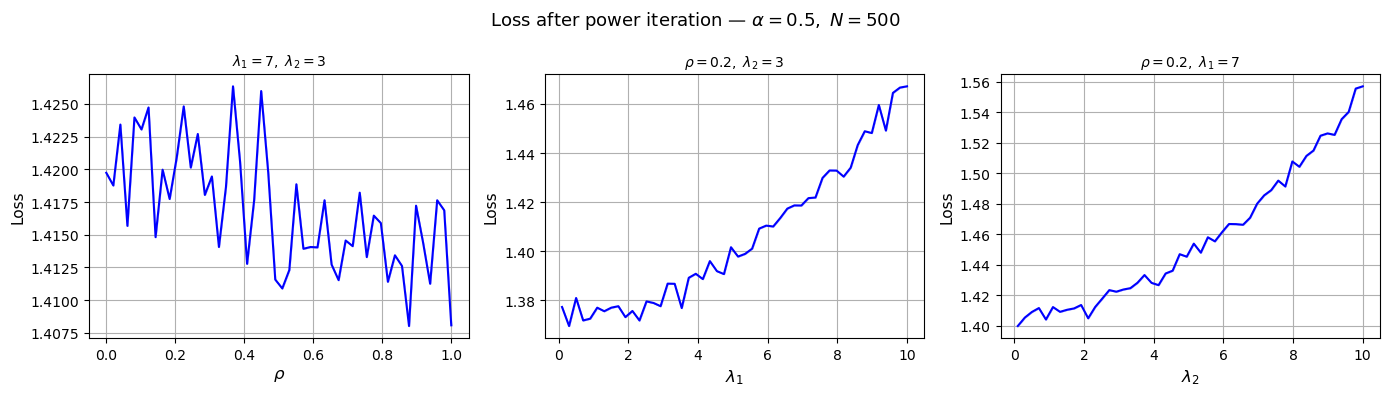

In [3]:
importlib.reload(m)

alpha = 0.5
N = 500
N_iter = 200
N_runs = 20

lamba_1_fixed = 7
lamba_2_fixed = 3
rho_fixed = 0.2

rhos     = np.linspace(0, 1, 50)
lambas_1 = np.linspace(0.1, 10, 50)
lambas_2 = np.linspace(0.1, 10, 50)

def run_metrics(M, N_runs, N_iter):
    all_loss = []
    for _ in range(N_runs):
        x_hat = np.random.normal(0, 1, N)
        x_hat /= np.linalg.norm(x_hat)
        for _ in range(N_iter):
            x_hat = M.matrix @ x_hat
            x_hat /= np.linalg.norm(x_hat)
        all_loss.append(M.loss(x_hat))
    return np.mean(all_loss), np.std(all_loss)

results = {"rho": [], "lam1": [], "lam2": []}

for rho in rhos:
    results["rho"].append(run_metrics(m.TwoSpikedWignerMatrix(N, lamba_1_fixed, lamba_2_fixed, rho, alpha), N_runs, N_iter))
for lam1 in lambas_1:
    results["lam1"].append(run_metrics(m.TwoSpikedWignerMatrix(N, lam1, lamba_2_fixed, rho_fixed, alpha), N_runs, N_iter))
for lam2 in lambas_2:
    results["lam2"].append(run_metrics(m.TwoSpikedWignerMatrix(N, lamba_1_fixed, lam2, rho_fixed, alpha), N_runs, N_iter))

for k in results:
    results[k] = np.array(results[k])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sweep_params = [
    (rhos,     results["rho"],  r"$\rho$",       rf"$\lambda_1={lamba_1_fixed},\ \lambda_2={lamba_2_fixed}$"),
    (lambas_1, results["lam1"], r"$\lambda_1$",  rf"$\rho={rho_fixed},\ \lambda_2={lamba_2_fixed}$"),
    (lambas_2, results["lam2"], r"$\lambda_2$",  rf"$\rho={rho_fixed},\ \lambda_1={lamba_1_fixed}$"),
]

for ax, (x, data, xlabel, subtitle) in zip(axes, sweep_params):
    ax.plot(x, data[:, 0], color='blue')
    ax.fill_between(x, data[:, 0] - data[:, 1], data[:, 0] + data[:, 1], alpha=0.2, color='blue')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Loss", fontsize=11)
    ax.set_title(subtitle, fontsize=10)
    ax.grid(True)

fig.suptitle(rf"Loss after power iteration — $\alpha={alpha},\ N={N}$", fontsize=13)
fig.tight_layout()

fig.savefig(f"../Plots/Spike/Loss_alpha={alpha:.2f}.png", dpi=200, bbox_inches="tight")
plt.show()

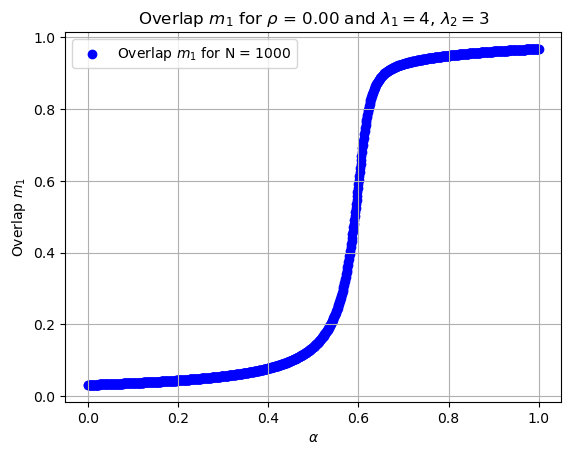

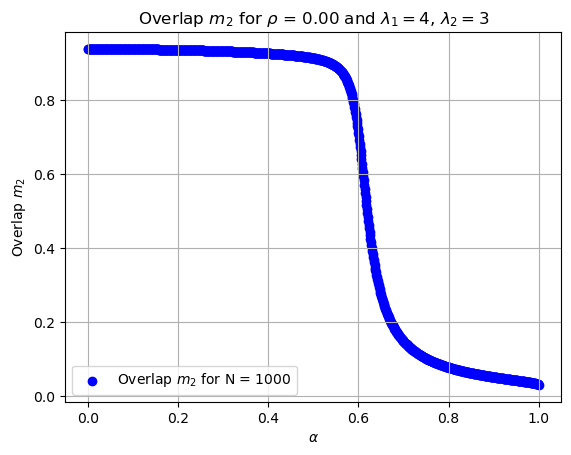

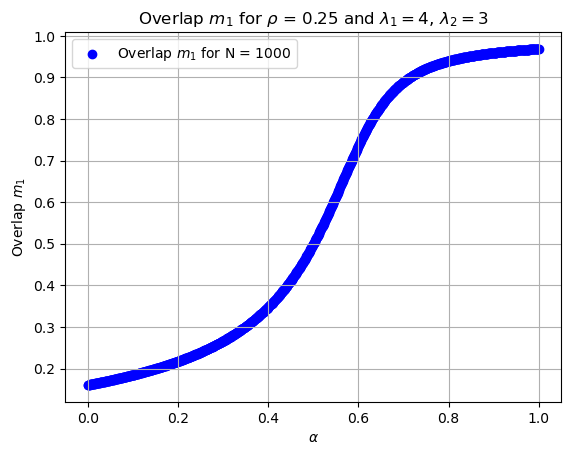

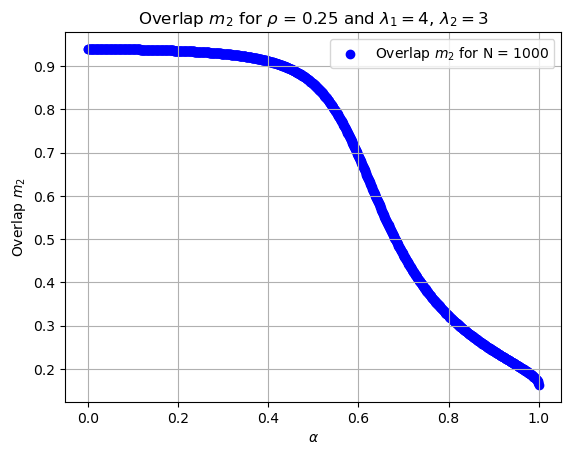

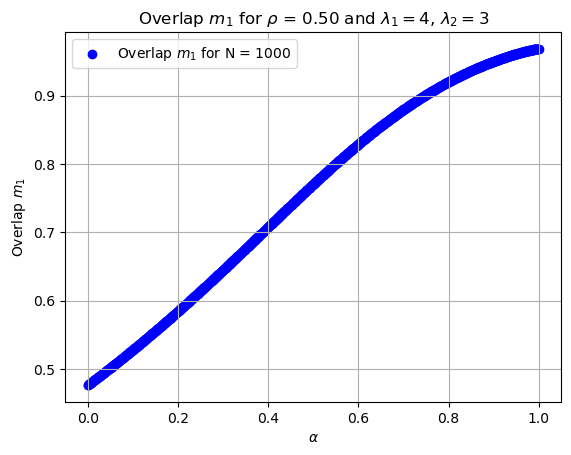

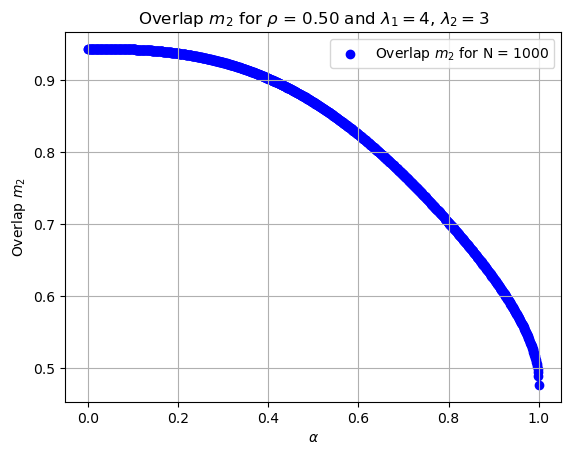

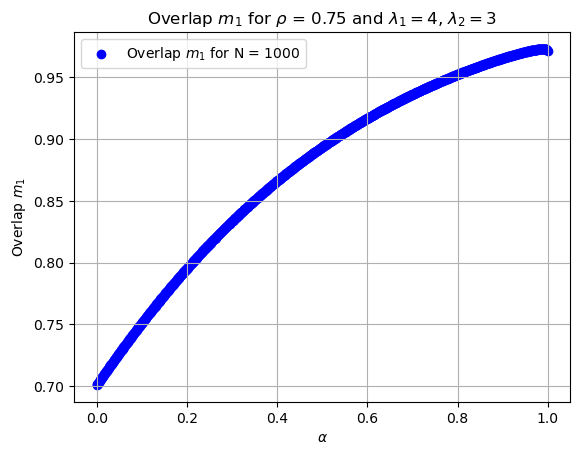

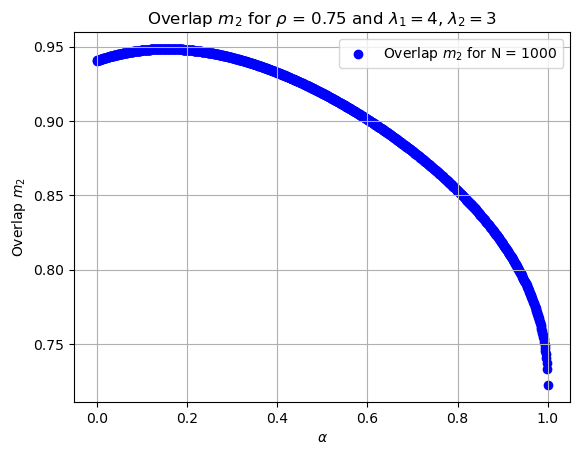

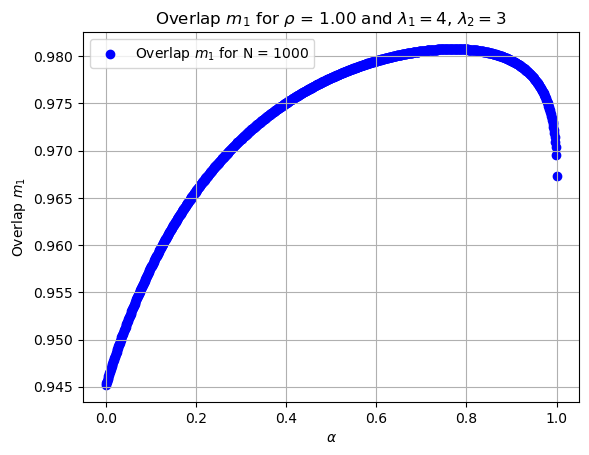

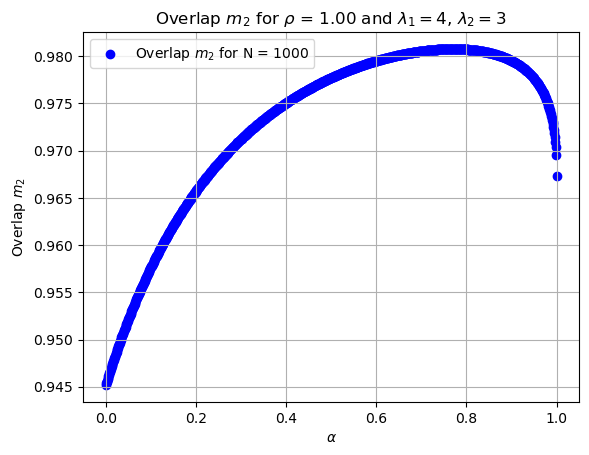

In [50]:
importlib.reload(m)

alphas = np.linspace(0, 1, 1000)
N = 1000
rhos = np.linspace(0, 1, 5)
lamba_1 = 4
lamba_2 = 3
# I will plot the loss as a function of alpha, each time I will degerate random values of x_hat, and average the loss over them
N_gradient_descent = 10000

for rho in rhos:
    M = m.TwoSpikedWignerMatrix(N, lamba_1, lamba_2, rho, 0)
    overlap_1 = []
    overlap_2 = []
    for alpha in alphas:
        M.new_alpha(alpha)
        x_hat = np.random.normal(0, 1, N)
        x_hat = x_hat / np.linalg.norm(x_hat)
        x_hat = M.power_iteration(x_hat, N_gradient_descent)
        overlap_1.append(M.overlap1(x_hat))
        overlap_2.append(M.overlap2(x_hat))
    plt.scatter(alphas, overlap_1, color='blue', label='Overlap $m_1$ for N = 1000')
    m.ploplote_moi_ca(xlabel=r'$\alpha$', ylabel=r'Overlap $m_1$', title=rf'Overlap $m_1$ for $\rho$ = {rho:.2f} and $\lambda_1 = 4$, $\lambda_2 = 3$', savefig=f'Overlap_m1_vs_Alpha_rho={rho:.2f}', grid=True, legend=True)
    plt.scatter(alphas, overlap_2, color='blue', label='Overlap $m_2$ for N = 1000')
    m.ploplote_moi_ca(xlabel=r'$\alpha$', ylabel=r'Overlap $m_2$', title=rf'Overlap $m_2$ for $\rho$ = {rho:.2f} and $\lambda_1 = 4$, $\lambda_2 = 3$', savefig=f'Overlap_m2_vs_Alpha_rho={rho:.2f}', grid=True, legend=True)

<ErrorbarContainer object of 3 artists>

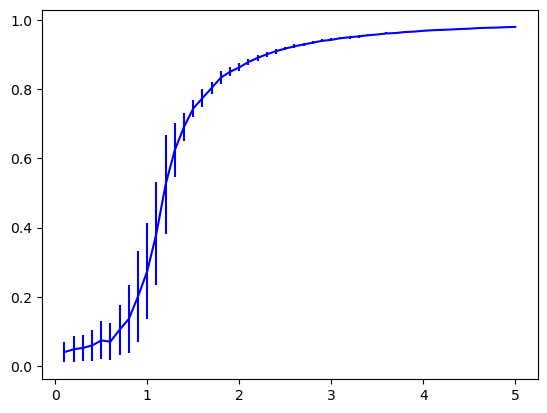

In [ ]:
#just plot overlap as a function of lamba here, for one spike:
importlib.reload(m)
N = 500
N_average = 50
M = m.SpikedWignerMatrix(N, 0) # we start with no spike, we will change lambda later
lambas = np.linspace(0.1, 5, 50)
overlap = []
theoretical_overlap = []
std_overlap = []
for lamba in lambas:
    x_avg = []
    for i in range(N_average):
        M = m.SpikedWignerMatrix(N, lamba)  # fresh Wigner + fresh spike each time
        x_hat = M.max_eigenvector()
        x_avg.append(M.overlap1(x_hat))
    #theoretical_overlap.append(M.theoretical_max_eigenvalue()-2)
    overlap.append(np.mean(x_avg))
    std_overlap.append(np.std(x_avg))
#plt.plot(lambas, overlap, color='blue')
plt.errorbar(lambas, overlap, yerr=std_overlap, color='blue')
#plt.plot(lambas, theoretical_overlap, color='red', linestyle='--')

In [ ]:
#Now lets try to plot when we recover x as a function of lamba. To do this, we plot the overlap as before as a function of lambda, then we add red color if the overlap is greater than a certain value that is 1e-2. For one spike first.

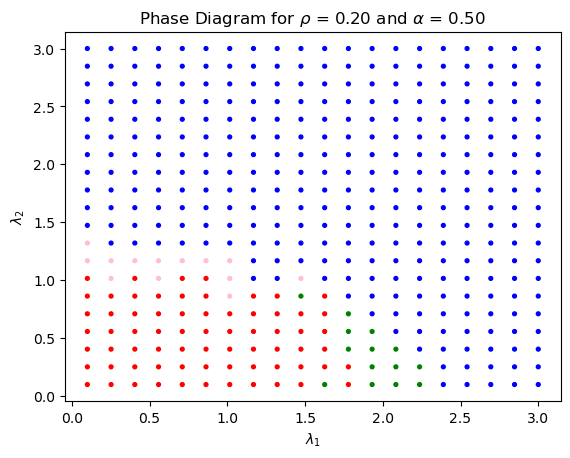

In [ ]:
importlib.reload(m)
N = 500
lambas1 = np.linspace(0.1, 5, 50)
lambas2 = np.linspace(0.1, 5, 50)
rho = 0.2
alphas = np.linspace(0, 1, 6)

N_gradient_descent = 10000
threshold = 0.1
N_average = 5

for alpha in alphas:
    x_vals, y_vals, colors = m.phase_diagram_parallel(N, rho, alpha, lambas1, lambas2, N_gradient_descent, threshold, N_average)
    plt.scatter(x_vals, y_vals, c=colors, s=1, marker='.')
    m.ploplote_moi_ca(xlabel=r'$\lambda_1$', ylabel=r'$\lambda_2$', title=rf'Phase Diagram for $\rho$ = {rho:.2f} and $\alpha$ = {alpha:.2f}', savefig=f'Phase_Diagram_rho={rho:.2f}_and_alpha={alpha:.2f}', grid=False, legend=False)